In [23]:
import pandas as pd
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from nltk.corpus import stopwords
from tqdm import tqdm

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from sklearn.metrics import accuracy_score, hamming_loss, jaccard_score

from gensim.models import Word2Vec

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import BertTokenizer, BertForSequenceClassification, AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import Trainer, TrainingArguments
import torch.nn as nn

from tqdm import tqdm

In [2]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
stopwords_ru = set(stopwords.words("russian"))
tqdm.pandas()

In [4]:
path = 'dataset.txt'

In [5]:
with open(path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

In [6]:
data = []
for line in lines:
    line = line.strip()
    if not line:
        continue

    if line.startswith('__label__'):
        parts = line.split(' ', 1)
        labels_str = parts[0]
        text = parts[1] if len(parts) > 1 else ''

        labels_clean = labels_str.replace('__label__', '').replace(' ', ',')
        data.append({'text': text, 'labels': labels_clean})

In [7]:
print(data[:2])

[{'text': 'скотина! что сказать', 'labels': 'INSULT'}, {'text': 'я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окраса. может, я и ошиблась, но необычный окрас бросился в глаза.', 'labels': 'NORMAL'}]


In [8]:
df = pd.DataFrame(data)

In [9]:
df.head(10)

,text,labels
0,скотина! что сказать,INSULT
1,я сегодня проезжала по рабочей и между домами ...,NORMAL
2,очередной лохотрон. зачем придумывать очередно...,NORMAL
3,"ретро дежавю ... сложно понять чужое сердце , ...",NORMAL
4,а когда мы статус агрогородка получили?,NORMAL
5,2 августа поздно вечером нашли вот такую потер...,NORMAL
6,вчера надыбала новые стикеры #u2a94ec7fabs#,NORMAL
7,заколоть этого плешивого урода что бы крякнул ...,"INSULT,THREAT"
8,а еще на стоянке никто не проверяет безопаснос...,NORMAL
9,"красота..!! если есть, что показать??!! почему...",NORMAL


In [10]:
df.shape

(248290, 2)

In [11]:
unique_labels = df['labels'].apply(tuple).unique()
unique_labels

array([('I', 'N', 'S', 'U', 'L', 'T'), ('N', 'O', 'R', 'M', 'A', 'L'),
       ('I', 'N', 'S', 'U', 'L', 'T', ',', 'T', 'H', 'R', 'E', 'A', 'T'),
       ('I', 'N', 'S', 'U', 'L', 'T', ',', 'O', 'B', 'S', 'C', 'E', 'N', 'I', 'T', 'Y'),
       ('O', 'B', 'S', 'C', 'E', 'N', 'I', 'T', 'Y'),
       ('T', 'H', 'R', 'E', 'A', 'T'),
       ('O', 'B', 'S', 'C', 'E', 'N', 'I', 'T', 'Y', ',', 'T', 'H', 'R', 'E', 'A', 'T'),
       ('I', 'N', 'S', 'U', 'L', 'T', ',', 'O', 'B', 'S', 'C', 'E', 'N', 'I', 'T', 'Y', ',', 'T', 'H', 'R', 'E', 'A', 'T')],
      dtype=object)

In [12]:
df.isna().sum()

,0
text,0
labels,0


In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stopwords_ru]
    return " ".join(tokens)

In [14]:
df["labels"] = df["labels"].progress_apply(lambda x: x.split(','))
df["text"] = df["text"].progress_apply(clean_text)

100%|██████████| 248290/248290 [00:42<00:00, 5854.13it/s]


In [15]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["labels"])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df["text"], y, test_size=0.2, random_state=42)

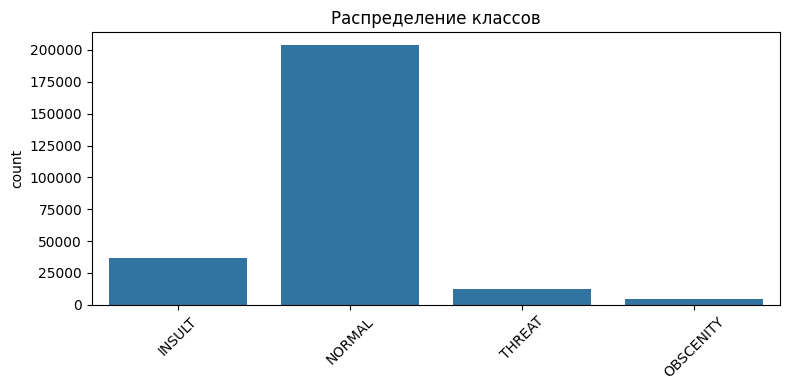

In [17]:
flat_labels = [label for sublist in df["labels"] for label in sublist]
plt.figure(figsize=(8,4))
sns.countplot(x=flat_labels)
plt.title("Распределение классов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
class_counts = np.sum(y_train, axis=0)
n_samples = len(y_train)
n_classes = len(mlb.classes_)

# Рассчитываем веса как обратную частоту класса
class_weights = n_samples / (n_classes * class_counts)
print("Веса классов:", class_weights)

Веса классов: [ 1.69111838  0.30462041 14.49868613  5.16893932]


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
import os
os.environ["WANDB_DISABLED"] = "true"

# 1. tf-idf + logreg

In [ ]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),  # Сначала указываем базовый TfidfVectorizer
    ("clf", MultiOutputClassifier(lr_model))
])

In [ ]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (2, 3)],  # Разные диапазоны n-грамм
    'tfidf__max_features': [10000, 20000, 30000],  # Разное количество признаков
}

In [ ]:
grid_search = GridSearchCV(pipe, param_grid, cv=3, n_jobs=1, verbose=0)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf',
                                        MultiOutputClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                                           max_iter=1000)))]),
             n_jobs=1,
             param_grid={'tfidf__max_features': [10000, 20000, 30000],
                         'tfidf__ngram_range': [(1, 1), (1, 2), (2, 3)]})

In [ ]:
print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 1)}


In [ ]:
joblib.dump(grid_search.best_estimator_, 'best_model_tfidf_logreg.pkl')

['best_model_tfidf_logreg.pkl']

In [ ]:
y_pred = grid_search.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

              precision    recall  f1-score   support

      INSULT       0.79      0.86      0.82      7462
      NORMAL       0.97      0.97      0.97     40669
   OBSCENITY       0.42      0.86      0.57       836
      THREAT       0.61      0.90      0.73      2420

   micro avg       0.90      0.95      0.92     51387
   macro avg       0.70      0.90      0.77     51387
weighted avg       0.92      0.95      0.93     51387
 samples avg       0.92      0.95      0.93     51387



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 2. Word2Vec + LogisticRegression

In [ ]:
sentences = [text.split() for text in X_train]

In [ ]:
class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=2, model_path=None):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.model_path = model_path  # Путь для сохранения модели
        self.model = None

    def fit(self, X, y=None):
        sentences = [text.split() for text in X]
        self.model = Word2Vec(
            sentences,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=4
        )
        if self.model_path:
            self.model.save(self.model_path)  # Сохраняем модель Word2Vec
        return self

    def transform(self, X):
        def vectorize(text):
            words = text.split()
            vectors = [self.model.wv[word] for word in words if word in self.model.wv]
            return np.mean(vectors, axis=0) if vectors else np.zeros(self.vector_size)
        return np.array([vectorize(text) for text in X])

In [ ]:
param_grid_w2v = {
    'w2v__vector_size': [400, 800],
    'w2v__window': [15, 30],
    'w2v__min_count': [7, 12],
}

In [ ]:
pipe_w2v = Pipeline([
    ('w2v', Word2VecTransformer(model_path="word2vec.model")),  # Указываем путь для сохранения
    ('clf', MultiOutputClassifier(LogisticRegression(class_weight='balanced', max_iter=1000)))
])

In [ ]:
grid_search_w2v = GridSearchCV(pipe_w2v, param_grid_w2v, cv=3, n_jobs=-1, verbose=1)

In [ ]:
grid_search_w2v.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('w2v',
                                        Word2VecTransformer(model_path='word2vec.model')),
                                       ('clf',
                                        MultiOutputClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                                           max_iter=1000)))]),
             n_jobs=-1,
             param_grid={'w2v__min_count': [7, 12],
                         'w2v__vector_size': [400, 800],
                         'w2v__window': [15, 30]},
             verbose=1)

In [ ]:
print("Лучшие параметры для Word2Vec + LogisticRegression:", grid_search_w2v.best_params_)

Лучшие параметры для Word2Vec + LogisticRegression: {'w2v__min_count': 12, 'w2v__vector_size': 400, 'w2v__window': 15}


In [ ]:
joblib.dump(grid_search_w2v.best_estimator_.named_steps['clf'], 'word2vec_logreg.pkl')

['word2vec_logreg.pkl']

In [ ]:
y_pred_w2v = grid_search_w2v.predict(X_test)
print(classification_report(y_test, y_pred_w2v, target_names=mlb.classes_))

              precision    recall  f1-score   support

      INSULT       0.52      0.80      0.63      7462
      NORMAL       0.96      0.88      0.92     40669
   OBSCENITY       0.07      0.79      0.13       836
      THREAT       0.32      0.85      0.46      2420

   micro avg       0.69      0.87      0.77     51387
   macro avg       0.47      0.83      0.54     51387
weighted avg       0.85      0.87      0.84     51387
 samples avg       0.77      0.87      0.80     51387



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 3. Transformer (RuBERT)

In [21]:
class ToxicCommentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = torch.tensor(self.labels[item], dtype=torch.float)

        # Токенизация текста
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': label
        }

In [25]:
rubert_model_name = "DeepPavlov/rubert-base-cased"  # Используем модель от DeepPavlov
tokenizer = AutoTokenizer.from_pretrained(rubert_model_name)
max_len = 128

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
train_dataset = ToxicCommentDataset(X_train.tolist(), y_train, tokenizer, max_len)
test_dataset = ToxicCommentDataset(X_test.tolist(), y_test, tokenizer, max_len)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

In [30]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(rubert_model_name, num_labels=y.shape[1])
model.to(device)

pytorch_model.bin:  44%|####4     | 315M/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
class CustomTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits

            # Используем BCEWithLogitsLoss с pos_weight для учета несбалансированности классов
            loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor)
            loss = loss_fct(logits, labels)

            return (loss, outputs) if return_outputs else loss

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    run_name='rubert_weighted_experiment',
    report_to="none",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
    logging_steps=2000,
)

In [ ]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer
)


<ipython-input-28-8f0087e0cc2e>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(


In [ ]:
trainer.train()

Step,Training Loss
2000,0.263900
4000,0.228200
6000,0.195000
8000,0.192800
10000,0.194600
12000,0.179200
14000,0.158100
16000,0.138700
18000,0.128000
20000,0.121200


KeyboardInterrupt: 

In [ ]:
trainer.evaluate()

{'eval_loss': 0.126765638589859}

In [ ]:
model.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_model")

('bert_model/tokenizer_config.json',
 'bert_model/special_tokens_map.json',
 'bert_model/vocab.txt',
 'bert_model/added_tokens.json',
 'bert_model/tokenizer.json')

#4. LSTM

In [37]:
class BiLSTMClassifier(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, padding_idx, class_weights):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim, num_layers=2,
                                  bidirectional=True, batch_first=True, dropout=0.3)
        self.dropout = torch.nn.Dropout(0.4)
        self.fc = torch.nn.Linear(hidden_dim * 2, output_dim)
        self.loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights)

    def forward(self, input_ids, labels=None):
        embedded = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embedded)
        pooled = torch.mean(lstm_out, dim=1)
        dropped = self.dropout(pooled)
        logits = self.fc(dropped)

        if labels is not None:
            loss = self.loss_fct(logits, labels)
            return loss, logits
        return logits

In [32]:
train_dataset = ToxicCommentDataset(X_train.tolist(), y_train, tokenizer, max_len)
test_dataset = ToxicCommentDataset(X_test.tolist(), y_test, tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [38]:
model = BiLSTMClassifier(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    output_dim=y_train.shape[1],
    padding_idx=tokenizer.pad_token_id,
    class_weights=class_weights_tensor.to(device)
).to(device)

In [39]:
loss_fn = nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [40]:
epochs = 10

In [42]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        loss, logits = model(input_ids, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 6208/6208 [04:27<00:00, 23.25it/s]


Epoch 1, Loss: 2059.8551


Epoch 2: 100%|██████████| 6208/6208 [04:08<00:00, 24.96it/s]


Epoch 2, Loss: 979.4090


Epoch 3: 100%|██████████| 6208/6208 [04:08<00:00, 24.97it/s]


...

Epoch 8, Loss: 251.9227


Epoch 9: 100%|██████████| 6208/6208 [04:08<00:00, 24.97it/s]


Epoch 9, Loss: 213.9822


Epoch 10: 100%|██████████| 6208/6208 [04:11<00:00, 24.68it/s]

Epoch 10, Loss: 177.2691


In [43]:
torch.save(model.state_dict(), "bilstm_model.pth")

# Загрузка моделей

In [46]:
pipe = joblib.load("best_model_tfidf_logreg.pkl")
w2v_model = Word2Vec.load("word2vec.model")
clf = joblib.load("word2vec_logreg.pkl")
tokenizer = BertTokenizer.from_pretrained("bert_model")
model = BertForSequenceClassification.from_pretrained("bert_model")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [52]:
lstm = BiLSTMClassifier(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    output_dim=y_train.shape[1],
    padding_idx=tokenizer.pad_token_id,
    class_weights=class_weights_tensor.to(device)
)
lstm.load_state_dict(torch.load("bilstm_model.pth", map_location=device))
lstm.to(device)

BiLSTMClassifier(
  (embedding): Embedding(119547, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=4, bias=True)
  (loss_fct): BCEWithLogitsLoss()
)

In [53]:
trainer = Trainer(model=model)
predictions = trainer.predict(test_dataset)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


# Тесты моделей

In [54]:
lstm.eval()
lstm_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        logits = lstm(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()
        lstm_preds.append(probs)
probs_lstm = np.vstack(lstm_preds)

In [55]:
def text_to_vector(text, w2v_model):
    words = text.split()  # или используйте более сложную токенизацию
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(w2v_model.vector_size)

# Преобразуем весь X_test
X_test_w2v = np.array([text_to_vector(text, w2v_model) for text in X_test])

In [56]:
y_pred_tfidf = pipe.predict(X_test)
y_pred_w2v = clf.predict(X_test_w2v)
probs_bert = torch.sigmoid(torch.tensor(predictions.predictions))
y_pred_bert = (probs_bert > 0.5).int().numpy()
y_pred_lstm = (probs_lstm > 0.5).astype(int)

In [61]:
macro_f1 = [
    f1_score(y_test, y_pred_tfidf, average='macro'),
    f1_score(y_test, y_pred_w2v, average='macro'),
    f1_score(y_test, y_pred_bert, average='macro'),
    f1_score(y_test, y_pred_lstm, average='macro')
]
micro_f1 = [
    f1_score(y_test, y_pred_tfidf, average='micro'),
    f1_score(y_test, y_pred_w2v, average='micro'),
    f1_score(y_test, y_pred_bert, average='micro'),
    f1_score(y_test, y_pred_lstm, average='micro')
]

results = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Word2Vec + LR', 'BERT', 'BiLSTM'],
    'Macro F1': macro_f1,
    'Micro F1': micro_f1
})
results

,Model,Macro F1,Micro F1
0,TF-IDF + LR,0.770946,0.924227
1,Word2Vec + LR,0.535776,0.769527
2,BERT,0.880128,0.962021
3,BiLSTM,0.861108,0.953068


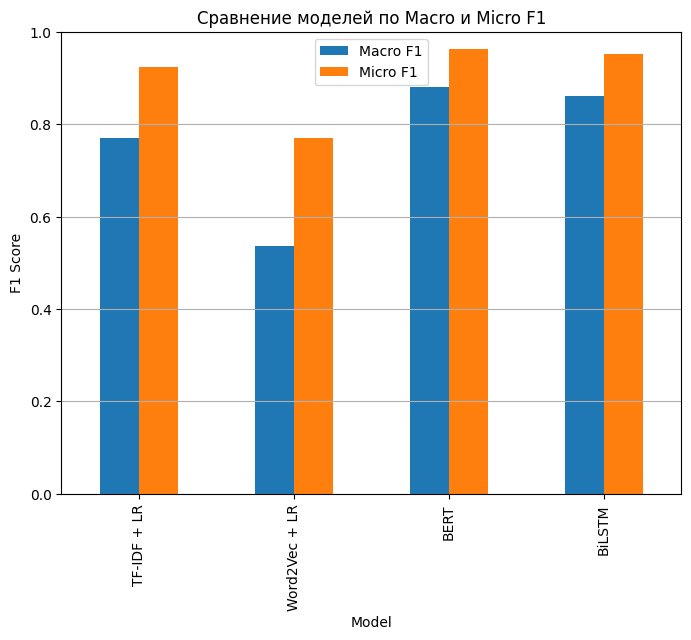

In [62]:
results.set_index('Model').plot(kind='bar', figsize=(8,6))
plt.title('Сравнение моделей по Macro и Micro F1')
plt.ylabel('F1 Score')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

In [63]:
def compute_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    ham = hamming_loss(y_true, y_pred)
    jac = jaccard_score(y_true, y_pred, average='samples')
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Hamming Loss": ham,
        "Jaccard": jac
    }

In [65]:
metrics = [
    compute_metrics(y_test, y_pred_tfidf, "TF-IDF + LR"),
    compute_metrics(y_test, y_pred_w2v, "Word2Vec + LR"),
    compute_metrics(y_test, y_pred_bert, "BERT"),
    compute_metrics(y_test, y_pred_lstm, "LSTM")
]

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Accuracy,Hamming Loss,Jaccard
0,TF-IDF + LR,0.892364,0.040195,0.921871
1,Word2Vec + LR,0.679870,0.134500,0.770441
2,BERT,0.950220,0.019670,0.960637
3,LSTM,0.936788,0.024347,0.950052


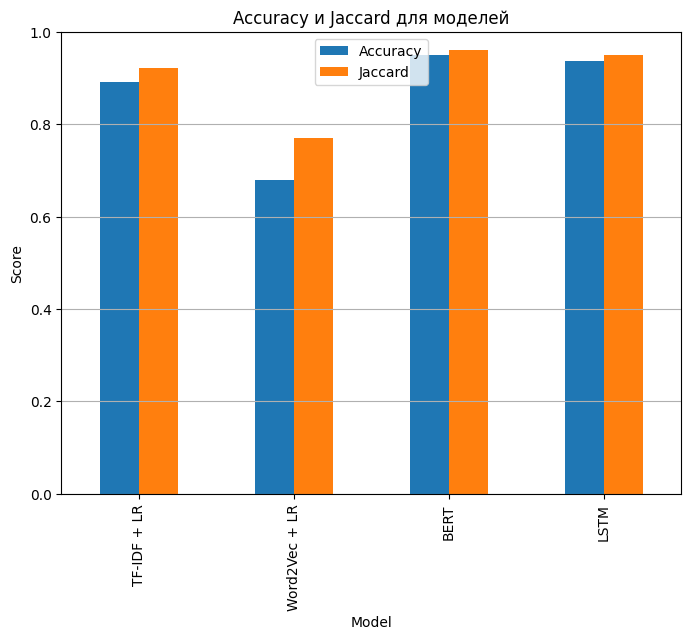

In [66]:
metrics_df.set_index("Model")[["Accuracy", "Jaccard"]].plot(kind='bar', figsize=(8, 6))
plt.title("Accuracy и Jaccard для моделей")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.grid(axis='y')
plt.show()

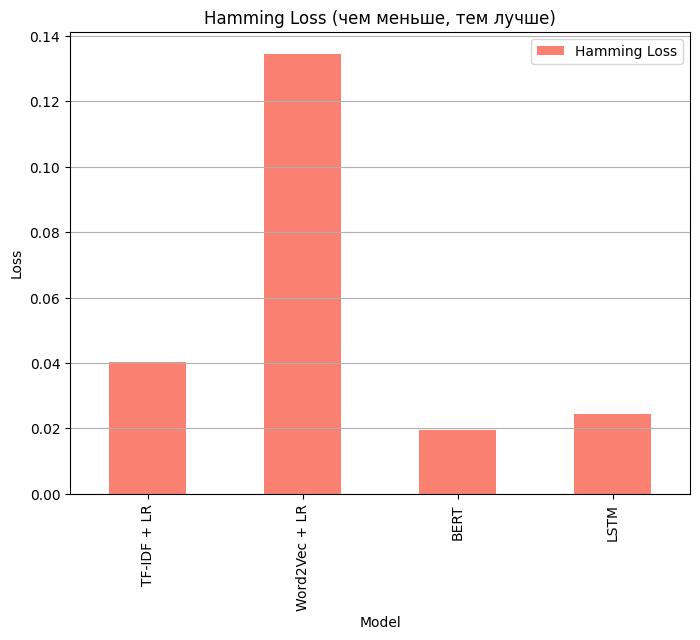

In [67]:
metrics_df.set_index("Model")[["Hamming Loss"]].plot(kind='bar', figsize=(8, 6), color='salmon')
plt.title("Hamming Loss (чем меньше, тем лучше)")
plt.ylabel("Loss")
plt.grid(axis='y')
plt.show()

### применим пороги классификации

In [68]:
def find_best_thresholds(probs, y_true, steps=20):
    optimal_thresholds = []
    for i in range(probs.shape[1]):
        best_thresh, best_f1 = 0.5, 0
        for thresh in np.linspace(0.1, 0.9, steps):
            preds = (probs[:, i] > thresh).astype(int)
            score = f1_score(y_true[:, i], preds)
            if score > best_f1:
                best_f1, best_thresh = score, thresh
        optimal_thresholds.append(best_thresh)
    return np.array(optimal_thresholds)

In [69]:
def apply_thresholds(probs, thresholds):
    preds = (probs > thresholds).astype(int)
    for i in range(len(preds)):
        if not preds[i].any():
            preds[i][probs[i].argmax()] = 1
    return preds

In [70]:
probs_tfidf = np.array([p[:, 1] for p in pipe.predict_proba(X_test)]).T
opt_thresh_tfidf = find_best_thresholds(probs_tfidf, y_test)

In [71]:
probs_w2v = np.array([p[:, 1] for p in clf.predict_proba(X_test_w2v)]).T
opt_thresh_w2v = find_best_thresholds(probs_w2v, y_test)

In [72]:
probs_bert_np = probs_bert.numpy()
opt_thresh_bert = find_best_thresholds(probs_bert_np, y_test)

In [73]:
opt_thresh_lstm = find_best_thresholds(probs_lstm, y_test)

In [74]:
pred_tfidf = apply_thresholds(probs_tfidf, opt_thresh_tfidf)
pred_w2v = apply_thresholds(probs_w2v, opt_thresh_w2v)
pred_bert = apply_thresholds(probs_bert_np, opt_thresh_bert)
pred_lstm = apply_thresholds(probs_lstm, opt_thresh_lstm)

In [75]:
macro_f1 = [
    f1_score(y_test, pred_tfidf, average='macro'),
    f1_score(y_test, pred_w2v, average='macro'),
    f1_score(y_test, pred_bert, average='macro'),
    f1_score(y_test, pred_lstm, average='macro')
]
micro_f1 = [
    f1_score(y_test, pred_tfidf, average='micro'),
    f1_score(y_test, pred_w2v, average='micro'),
    f1_score(y_test, pred_bert, average='micro'),
    f1_score(y_test, pred_lstm, average='micro')
]

results = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Word2Vec + LR', 'BERT', 'BiLSTM'],
    'Macro F1': macro_f1,
    'Micro F1': micro_f1
})

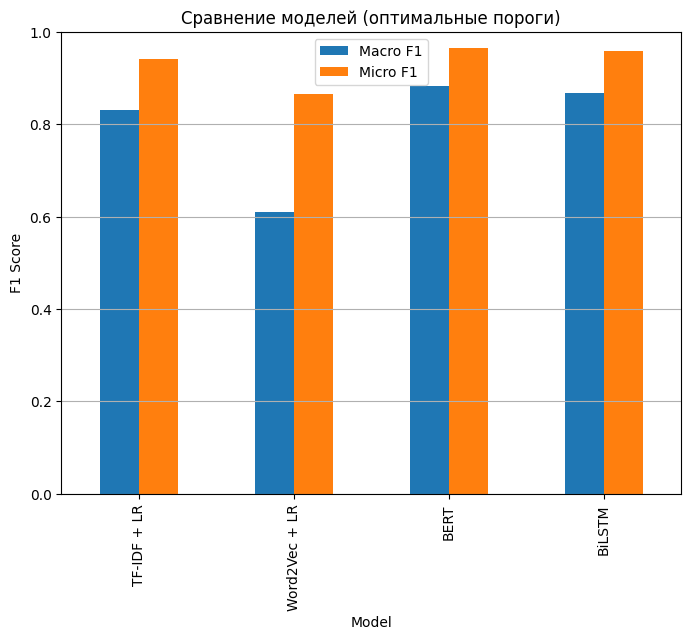

In [76]:
results.set_index('Model').plot(kind='bar', figsize=(8,6))
plt.title('Сравнение моделей (оптимальные пороги)')
plt.ylabel('F1 Score')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

In [77]:
metrics = [
    compute_metrics(y_test, pred_tfidf, "TF-IDF + LR"),
    compute_metrics(y_test, pred_w2v, "Word2Vec + LR"),
    compute_metrics(y_test, pred_bert, "BERT"),
    compute_metrics(y_test, pred_lstm, "BiLSTM")
]

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Accuracy,Hamming Loss,Jaccard
0,TF-IDF + LR,0.924262,0.030715,0.940344
1,Word2Vec + LR,0.824761,0.072521,0.865591
2,BERT,0.952596,0.018446,0.963806
3,BiLSTM,0.943816,0.022031,0.957066


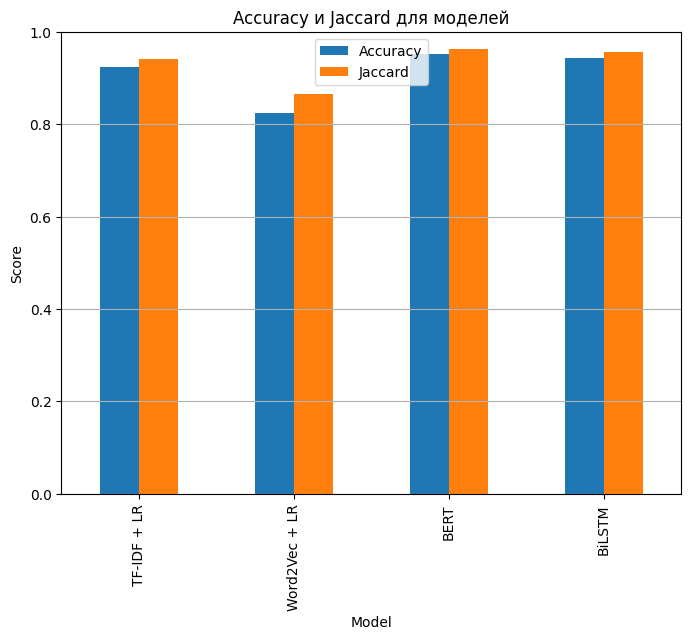

In [78]:
metrics_df.set_index("Model")[["Accuracy", "Jaccard"]].plot(kind='bar', figsize=(8, 6))
plt.title("Accuracy и Jaccard для моделей")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.grid(axis='y')
plt.show()

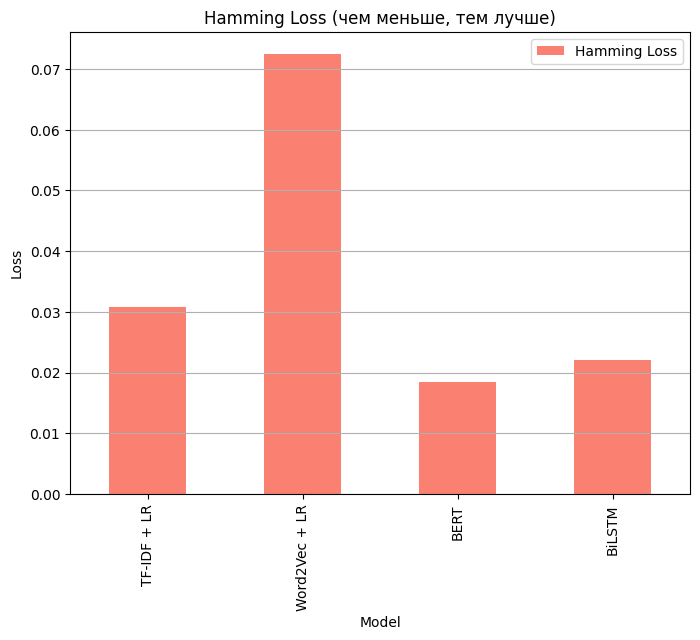

In [79]:
metrics_df.set_index("Model")[["Hamming Loss"]].plot(kind='bar', figsize=(8, 6), color='salmon')
plt.title("Hamming Loss (чем меньше, тем лучше)")
plt.ylabel("Loss")
plt.grid(axis='y')
plt.show()

In [81]:
idx = np.random.choice(len(X_test), size=10, replace=False)
for i in idx:
    text = X_test.iloc[i] if isinstance(X_test, pd.Series) else X_test[i]
    true_labels = [mlb.classes_[j] for j in np.where(y_test[i] == 1)[0]]
    pred_1 = [mlb.classes_[j] for j in np.where(pred_tfidf[i] == 1)[0]]
    pred_2 = [mlb.classes_[j] for j in np.where(pred_w2v[i] == 1)[0]]
    pred_3 = [mlb.classes_[j] for j in np.where(pred_bert[i] == 1)[0]]
    pred_4 = [mlb.classes_[j] for j in np.where(pred_lstm[i] == 1)[0]]

    print(f"\nТекст: {text[:300]}...")
    print(f"Истинные метки: {true_labels}")
    print(f"TF-IDF предсказал: {pred_1}")
    print(f"Word2Vec предсказал: {pred_2}")
    print(f"BERT предсказал: {pred_3}")
    print(f"BiLSTM предсказал: {pred_4}")


Текст: ...
Истинные метки: ['NORMAL']
TF-IDF предсказал: ['NORMAL']
Word2Vec предсказал: ['NORMAL']
BERT предсказал: ['NORMAL']
BiLSTM предсказал: ['NORMAL']

Текст: машины забрать...
Истинные метки: ['NORMAL']
TF-IDF предсказал: ['NORMAL']
Word2Vec предсказал: ['NORMAL']
BERT предсказал: ['NORMAL']
BiLSTM предсказал: ['NORMAL']

Текст: пол года учебка...
Истинные метки: ['NORMAL']
TF-IDF предсказал: ['NORMAL']
Word2Vec предсказал: ['NORMAL']
BERT предсказал: ['NORMAL']
BiLSTM предсказал: ['NORMAL']

Текст: мразь молодец олечка прав лукашенко уподобился януковичу своему беркута запретил применять силу оставив растерзание вооруженной толпы...
Истинные метки: ['INSULT']
TF-IDF предсказал: ['INSULT']
Word2Vec предсказал: ['INSULT']
BERT предсказал: ['INSULT']
BiLSTM предсказал: ['INSULT', 'THREAT']

Текст: красивая пара счастья...
Истинные метки: ['NORMAL']
TF-IDF предсказал: ['NORMAL']
Word2Vec предсказал: ['NORMAL']
BERT предсказал: ['NORMAL']
BiLSTM предсказал: ['NORMAL']

Текст: умны